Takes the SST tropical proxy data and matches it to the plasim-genie models they most resemble

In [3]:
import imageio
import glob
from gplately import pygplates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pygmt
import re
import shutil
import sys
import xarray as xr

In [18]:
ages = list(np.arange(0,260,10)) # Ages that we simulated temperature for
var = 'puma_temperature_surface_air' #variable name to get aves from (probably air temp)

colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']

# Grossman and Joachimski (2022) paleotemperature data (from publication's supplementary data)
grossmanVar = pd.ExcelFile('/Users/jono/Documents/Databases/paleotemperatures_Grossman_Joachimski_2022/41598_2022_11493_MOESM7_ESM.xlsx')
grossmanVar = pd.read_excel(grossmanVar, 'Table S2', skiprows=1) # Read the specific sheet
paleoTempLabel = "grossman2022_paleotemp"

# Get the paths to the climate models
model_path = '/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign'
climateModel = '2024-07-23_earthbyte_paleo_PaleomagRef' # Name of the climate model to use
co2s=['100','200','280','560','1120','2240','4480','fosterCO2']
models=[]
for co2 in co2s:
    model = os.path.join(model_path,f'{climateModel}_{co2}')
    # model = os.path.join(model_path,f'2024-10-08_scotese_paleo_{co2}ppm_shallowSea_{co2}')

    models.append(model)

In [14]:
# Do the same for the Grossman and Joachimski data
df = grossmanVar[grossmanVar['Age [Ma]'].isin(ages)][['Age [Ma]', 'Locfit mean T (PO4+CaCO3; iceV, lat, arag, bel corr)']].set_index('Age [Ma]').rename(columns={'Locfit mean T (PO4+CaCO3; iceV, lat, arag, bel corr)': 'paleoTemp'})   

# Apply a linear interpolation of NaN values
df = df.interpolate(method='linear', limit_direction='both')


In [22]:
# The Grossman values are for ocean temepratures between -30 and 30 degrees, so we only extract these values from the climate models
varSST = 'temp'
for i in range(len(models)):
    model = models[i]
    co2 = co2s[i]
    # for age in ages:
    for age in ages:
        plasimGrid = f'{model}/{str(age)}Ma_nc_outputs/3000-12-30_plasim.nc'
        goldsteinGrid = f'{model}/{str(age)}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'

        if not os.path.exists(plasimGrid):
            print(f'{plasimGrid} does not exist, continuing but this may not work')
            continue

        # Get the grid data
        ds = xr.open_dataset(goldsteinGrid)
        SSTs = ds[varSST][0][0]

        # Slice the grid to between lats of -30 and 30 degrees
        SSTsTropical = SSTs.sel(latitude=slice(-30, 30))

        info = pygmt.grdinfo(grid=SSTsTropical, per_column=True, force_scan='2', verbose="e")

        mean = round(float(info.split()[10]), 4)
        # # Calculate the mean temperature for these indices
        # mean_temp = np.mean(gridData[indices])

        df.at[age,co2] = mean

df

grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/0Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/10Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/20Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coor

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/90Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/220Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_100/230Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of co

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/40Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/50Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_200/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


...

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/100Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work
/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/110Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/240Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_280/250Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of co

/Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_fosterCO2/0Ma_nc_outputs/3000-12-30_plasim.nc does not exist, continuing but this may not work


grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_fosterCO2/140Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The step size of coordinate (latitude [degrees_north]) in grid /Users/jono/OneDrive - The University of Sydney (Staff)/paleoReef/climateModelData_OGnorealign/2024-07-23_earthbyte_paleo_PaleomagRef_fosterCO2/150Ma_nc_outputs/gold_spn_av_0000003000_00.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.58734; the original ranges from 5.53997 to 6.19537.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
grdinfo [WARNING]: The ste

,paleoTemp,100,200,280,560,1120,2240,4480,fosterCO2
Age [Ma],,,,,,,,,
0,23.500000,17.4448,23.1051,25.9410,29.3175,31.8781,34.2866,36.6842,NaN
10,23.318350,17.2274,23.2087,26.1586,29.0812,31.4706,33.7780,36.1921,26.5052
20,23.774086,18.0549,23.1666,26.9242,29.9777,32.3267,34.4626,36.9572,27.8969
30,24.718716,18.7734,23.9756,26.5612,30.0047,32.4230,34.5055,37.0595,31.0335
40,25.663345,19.2466,NaN,26.9903,30.1619,32.5244,34.8657,37.6356,31.3522
50,26.392484,NaN,NaN,26.8983,30.0244,32.5627,34.6422,37.4698,31.4898
60,25.121424,19.3866,24.2196,26.2694,29.8146,32.5004,34.5221,37.4639,27.6801
70,21.843821,19.6276,23.7160,27.0819,30.4284,32.6730,34.9456,37.9150,27.6382
80,25.626744,19.2486,24.1395,26.9320,30.6016,32.8593,34.7878,37.7718,31.3643


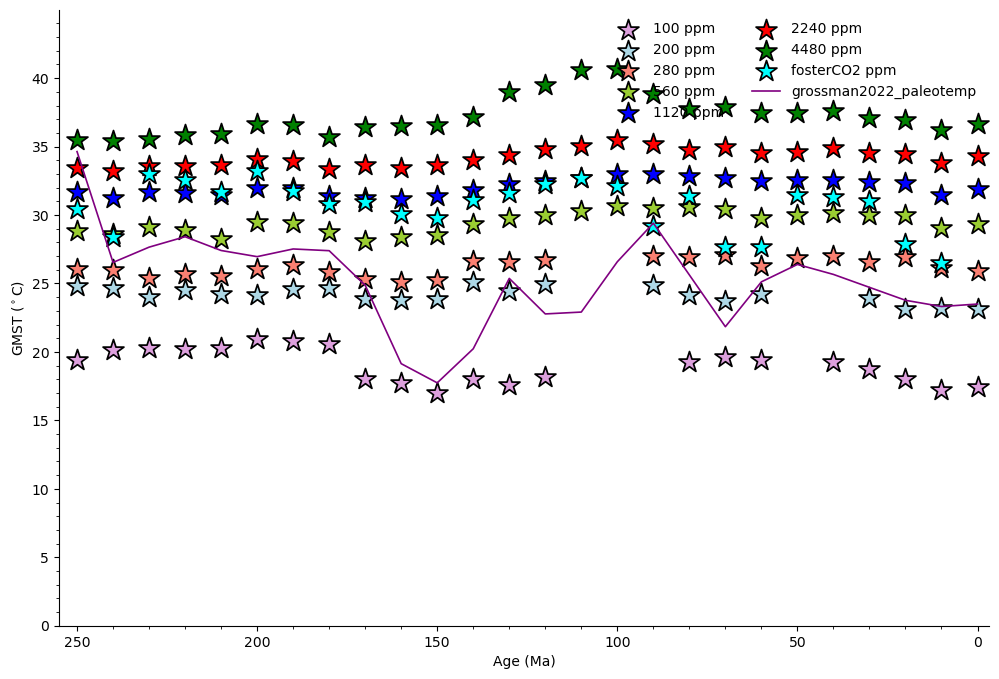

In [23]:
outdir = 'co2_GMST'
if os.path.exists(outdir):
    shutil.rmtree(outdir)
os.makedirs(outdir)

fig, ax = plt.subplots(figsize=(12,8))

# Set Y-axis limits
ax.set_ylim(0, 45)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 45, 5))
ax.set_xticks(np.arange(0, 251, 50))

ax.set_yticks(np.arange(0, 44.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('GMST ($^\circ$C)')

i=0
for co2 in co2s:
    # print(co2)
    try:
        ax.scatter(x=df.index,y=df[co2], marker='*', facecolors=colours[i], edgecolors='black', linewidths=1.25, s=250,  label=f'{co2} ppm')
    except Exception as e:
       print(e)
       pass
    co2name = co2
    try:
        int(co2)
    except Exception as e:
        # print(e)
        co2name = 'fosterCO2'
    # Hide the right and top spines
    ax.spines[['right', 'top']].set_visible(False)
    plt.savefig(f'{outdir}/{co2name}_gmst_comparison.png')
    i+=1


ax.plot(df.index, df['paleoTemp'], linewidth=1.2, color='purple', linestyle='-', label=paleoTempLabel)
ax.legend(loc='upper right', ncol=2, frameon=False) 

In [40]:
import imageio
import re
### animation
def animation(directory,name='animation.gif'):
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

animation(outdir)

100_gmst_comparison.png
200_gmst_comparison.png
280_gmst_comparison.png
560_gmst_comparison.png
1120_gmst_comparison.png
2240_gmst_comparison.png
4480_gmst_comparison.png
fosterCO2_gmst_comparison.png


In [41]:
# New dataframe that has how far each simulation is off the Scotese reconstruction
dfDiff = pd.DataFrame()
for co2 in co2s:
    dfDiff[co2] = np.abs(dfGrossman['Grossman'] - dfGrossman[co2])

# Create a dictionary that has the closest match model for each age
modelDict = {}
for age in dfDiff.index:
    closestModel = dfDiff.loc[age].idxmin()
    modelDict[age] = closestModel

modelDict # Dictionary of model to use that is closest to Scotese global temps for each age


{0: '280',
 10: '280',
 20: '280',
 30: '280',
 40: '280',
 50: '280',
 60: '280',
 70: '200',
 80: '280',
 90: '560',
 100: '560',
 110: '560',
 120: '200',
 130: '280',
 140: '200',
 150: '100',
 160: '200',
 170: '280',
 180: '560',
 190: '560',
 200: '560',
 210: '560',
 220: '560',
 230: '560',
 240: 'fosterCO2',
 250: '4480'}

In [42]:
dfDiff

,100,200,280,560,1120,2240,4480,fosterCO2
Age [Ma],,,,,,,,
0,8.099100,2.204300,0.802300,4.248600,6.845500,9.316700,11.808900,NaN
10,8.187350,1.601850,1.272850,4.222650,6.705550,9.024550,11.477250,1.654250
20,7.021486,2.059286,1.590014,4.632314,7.047114,9.290714,11.861314,2.550114
30,7.859916,2.509916,0.220884,3.686784,6.160584,8.297284,10.922884,4.696084
40,8.382345,NaN,0.205845,2.921455,5.358255,7.732855,10.527555,4.146955
50,NaN,NaN,1.032684,2.063716,4.648316,6.812316,9.679316,3.546716
60,7.600424,2.496224,0.329824,3.192276,5.854976,7.970576,10.953676,1.095276
70,4.100521,0.293779,3.772579,7.114979,9.390379,11.675779,14.726379,4.345779
80,8.369244,3.184844,0.214544,3.361756,5.635956,7.711456,10.744956,4.107356


100
200
280
560
1120
2240
4480
fosterCO2


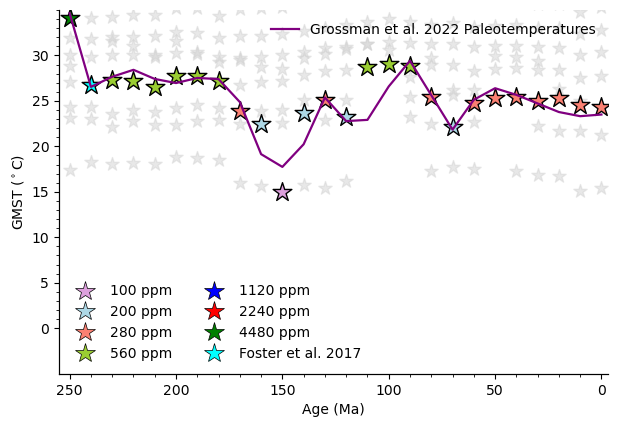

In [43]:
colours = ['plum','lightblue','salmon','yellowgreen','blue','red','green','cyan','orange','pink']
colourDict = {}
import matplotlib.lines as mlines
markers = []
labels = []
for i in range(len(co2s)):
    co2 = co2s[i]
    colour = colours[i]
    colourDict[co2] = colour

    # Legend
    marker = mlines.Line2D([], [], color=colour, marker='*', linestyle='None', markersize=15, markeredgewidth=0.5, markeredgecolor='black', label=f'{co2}')
    markers.append(marker)

    if co2 == 'fosterCO2':
        label = 'Foster et al. 2017'
    else:
        label = f'{co2} ppm'
    labels.append(label)
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(-5, 35)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 35, 5))
ax.set_xticks(np.arange(0, 251, 50))

ax.set_yticks(np.arange(0, 35.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(dfGrossman.index, dfGrossman['Grossman'], linewidth=1.6, color='purple', linestyle='-', label='Scotese, 2021')
i=0
for i in range(len(co2s)):
    co2 = co2s[i]
    print(co2)
    try:
        ax.scatter(x=dfGrossman.index,y=dfGrossman[co2], marker='*', facecolors='lightgrey', edgecolors=None, linewidths=1, s=100, alpha=0.5)
    except:
        continue
    i+=1
for age in modelDict:
    co2 = modelDict[age]
    try:
        ax.scatter(x=age,y=dfGrossman.loc[age,co2], marker='*', facecolors=colourDict[co2], edgecolors='black', linewidths=1, s=200)
    except:
        continue
    

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('GMST ($^\circ$C)')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

ax.legend(markers, labels, loc='best', ncol=2, frameon=False)

ax2 = ax.twinx()
ax2.plot(np.NaN, np.NaN, linewidth=1.6, color='purple', linestyle='-', label='Grossman et al. 2022 Paleotemperatures')
ax2.get_yaxis().set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)

ax2.legend(frameon=False)

plt.savefig(f'gmst_comparison_optimum.png', dpi=300)









In [44]:
# Write the modelDict to a txt file
with open(f'preferredCO2_{climateModel}_grossman2022.txt', 'w') as f:
    for age, model in modelDict.items():
        f.write(f'{age}\t{model}\n')


